In [1]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import random

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [2]:
# REPRODUCIBILITY
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)



In [3]:
# LOAD DATASET

url = "https://archive.ics.uci.edu/static/public/235/data.csv"

df = pd.read_csv(url, na_values=["?"], low_memory=False)

print(df.head())



         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  


In [4]:
# DATA PREPROCESSING

for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

df = df.ffill()

df = df.iloc[:100000]



In [5]:
# FEATURE ENGINEERING

df['hour'] = df.index.hour
df['day'] = df.index.dayofweek

df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['day_sin'] = np.sin(2*np.pi*df['day']/7)
df['day_cos'] = np.cos(2*np.pi*df['day']/7)

df.drop(['hour','day'], axis=1, inplace=True)

features = df.columns.tolist()
target_col = 'Global_active_power'
target_index = df.columns.get_loc(target_col)



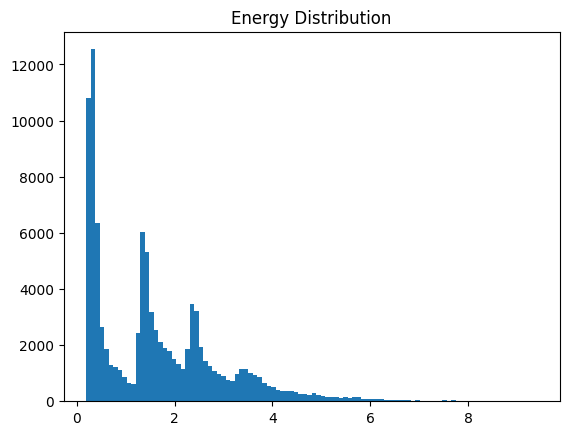

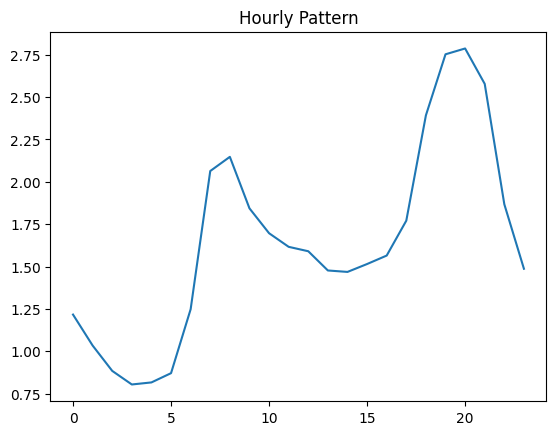

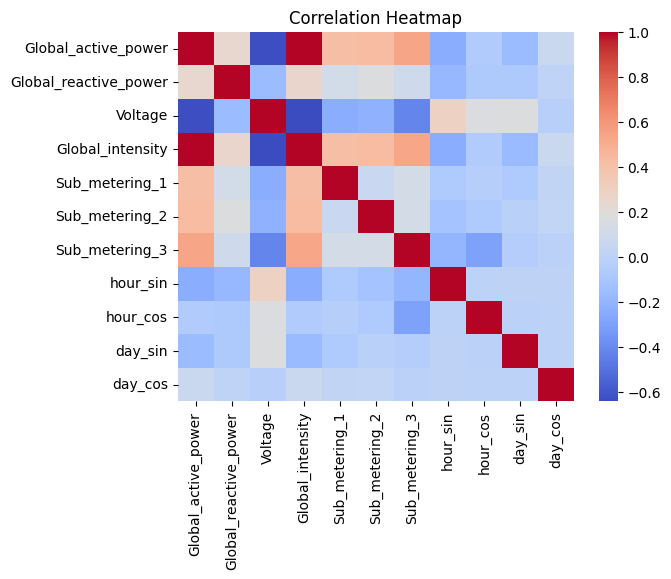

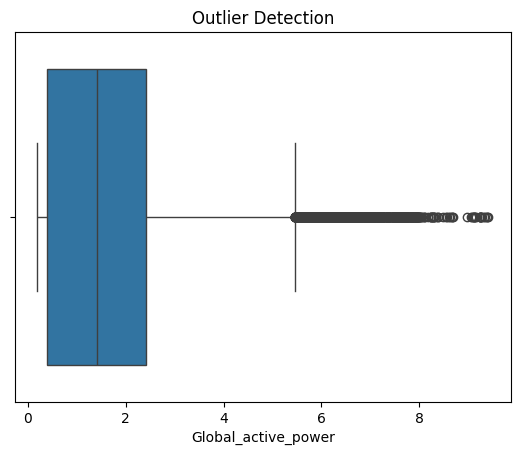

In [6]:
# EDA

plt.figure()
plt.hist(df['Global_active_power'], bins=100)
plt.title("Energy Distribution")
plt.show()

hourly = df.groupby(df.index.hour)['Global_active_power'].mean()
plt.figure()
plt.plot(hourly)
plt.title("Hourly Pattern")
plt.show()

sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# OUTLIER DETECTION (kept)
sns.boxplot(x=df['Global_active_power'])
plt.title("Outlier Detection")
plt.show()



In [7]:
# TRAIN-TEST SPLIT

train_size = int(0.8 * len(df))

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

train_scaled_df = pd.DataFrame(train_scaled, columns=df.columns)
test_scaled_df = pd.DataFrame(test_scaled, columns=df.columns)



In [8]:
# DATASET CLASS

SEQ_LENGTH = 60

class PowerDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        X = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length][target_index]

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor([y], dtype=torch.float32)
        )

train_dataset = PowerDataset(train_scaled_df.values, SEQ_LENGTH)
test_dataset = PowerDataset(test_scaled_df.values, SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)



In [9]:
# AUTOENCODER
class Autoencoder(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_size)
        )

    def forward(self, x):
        b, s, f = x.shape
        x = x.view(b*s, f)
        z = self.encoder(x)
        out = self.decoder(z)
        return out.view(b, s, f)

autoencoder = Autoencoder(len(features)).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(3):
    total = 0
    for xb, _ in train_loader:
        xb = xb.to(device)

        optimizer.zero_grad()
        recon = autoencoder(xb)
        loss = criterion(recon, xb)
        loss.backward()
        optimizer.step()

        total += loss.item()

    print("AE Epoch", epoch+1, total/len(train_loader))

# AUTOENCODER EVALUATION (FIXED)
autoencoder.eval()
ae_loss = 0

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        ae_loss += criterion(autoencoder(xb), xb).item()

print("Autoencoder Test Loss:", ae_loss/len(test_loader))



AE Epoch 1 0.001798561306900667
AE Epoch 2 1.8711057223294118e-05
AE Epoch 3 1.5733346914794912e-05
Autoencoder Test Loss: 4.509355537680612e-06


In [10]:
# AUTOENCODER FULL EVALUATION
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

autoencoder.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)

        recon = autoencoder(xb)

        # flatten sequence back
        recon = recon.cpu().numpy().reshape(-1, len(features))
        xb = xb.cpu().numpy().reshape(-1, len(features))

        all_pred.append(recon)
        all_true.append(xb)

all_pred = np.vstack(all_pred)
all_true = np.vstack(all_true)

# Metrics
ae_mae = mean_absolute_error(all_true, all_pred)
ae_rmse = np.sqrt(mean_squared_error(all_true, all_pred))
ae_r2 = r2_score(all_true, all_pred)

print("AUTOENCODER PERFORMANCE")
print("MAE  :", ae_mae)
print("RMSE :", ae_rmse)
print("R2   :", ae_r2)

AUTOENCODER PERFORMANCE
MAE  : 0.0014984153676778078
RMSE : 0.0021224452035591176
R2   : 0.9998243451118469


In [11]:
# ATTENTION LSTM

class AttentionLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, 2, batch_first=True)
        self.attn = nn.Linear(64, 1)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        w = torch.softmax(self.attn(out), dim=1)
        c = torch.sum(w * out, dim=1)
        return self.fc(c)



In [12]:
# TEMPORAL CNN

class TemporalCNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.conv1 = nn.Conv1d(input_size, 64, 3, padding=2, dilation=2)
        self.conv2 = nn.Conv1d(64, 64, 3, padding=4, dilation=4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)



In [13]:
# TRAIN FUNCTION

def train_model(model, epochs=20):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for e in range(epochs):
        total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

            total += loss.item()

        print("Epoch", e+1, total/len(train_loader))

    return model

att_model = train_model(AttentionLSTM(len(features)))
cnn_model = train_model(TemporalCNN(len(features)))



Epoch 1 0.005871567985121845
Epoch 2 0.002104320001380285
Epoch 3 0.0016934887258108708
Epoch 4 0.0016201332513710181
Epoch 5 0.0015496926105161915
Epoch 6 0.001489878115233903
Epoch 7 0.0014164232460392205
Epoch 8 0.001335387568341313
Epoch 9 0.001271725545631766
Epoch 10 0.0012281879447598322
Epoch 11 0.0011947696395229902
Epoch 12 0.0011530103734958557
Epoch 13 0.0011193888580781131
Epoch 14 0.001089975146809558
Epoch 15 0.001055702192896773
Epoch 16 0.0010377186899356984
Epoch 17 0.0010070304449544898
Epoch 18 0.0009824873043046774
Epoch 19 0.0009666863732224632
Epoch 20 0.0009448068982334409
Epoch 1 0.004547911900054973
Epoch 2 0.002417255947313017
Epoch 3 0.002257706767062516
Epoch 4 0.0021649314469669766
Epoch 5 0.0020980700970116427
Epoch 6 0.002046356941434965
Epoch 7 0.0020128224195297374
Epoch 8 0.0019754662631671204
Epoch 9 0.001941279870288472
Epoch 10 0.0019190297724493053
Epoch 11 0.0018853739049821282
Epoch 12 0.0018567748374698422
Epoch 13 0.0018232904554346763
Epoch 1

Attention LSTM
MAE 0.01714450679719448
RMSE 0.03344755799103088
R2 0.9515460133552551


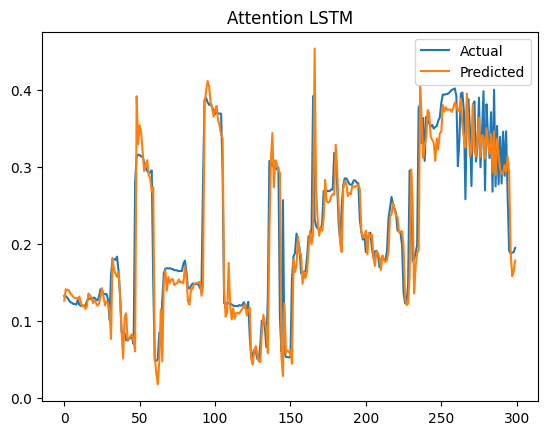

Temporal CNN
MAE 0.020033983513712883
RMSE 0.040842705042145384
R2 0.9277514219284058


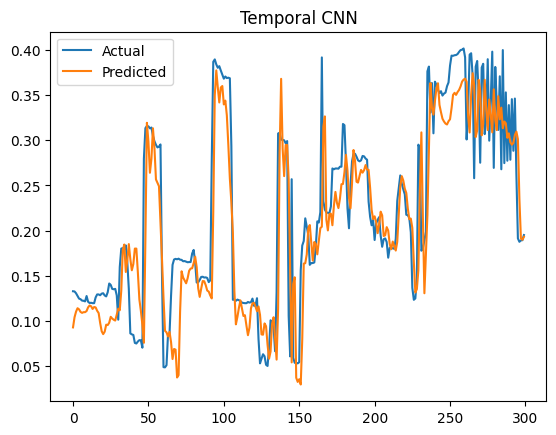

In [14]:
# EVALUATION
def evaluate(model, name):
    model.eval()
    p, t = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb).cpu().numpy()
            p.append(out)
            t.append(yb.numpy())

    p = np.vstack(p)
    t = np.vstack(t)

    print(name)
    print("MAE", mean_absolute_error(t, p))
    print("RMSE", np.sqrt(mean_squared_error(t, p)))
    print("R2", r2_score(t, p))

    plt.figure()
    plt.plot(t[:300], label="Actual")
    plt.plot(p[:300], label="Predicted")
    plt.legend()
    plt.title(name)
    plt.show()

evaluate(att_model, "Attention LSTM")
evaluate(cnn_model, "Temporal CNN")



In [15]:
# HYPERPARAMETER TUNING

from itertools import product

param_grid = {
    "hidden_size": [64, 128],
    "num_layers": [1, 2],
    "learning_rate": [0.001, 0.0005]
}

best_rmse = float("inf")
best_model = None
best_params = None

def train_and_validate(h, l, lr):

    model = nn.LSTM(len(features), h, l, batch_first=True).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(3):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            out, _ = model(xb)
            loss = loss_fn(out[:, -1, :1], yb)
            loss.backward()
            opt.step()

    preds, true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out, _ = model(xb)
            preds.append(out[:, -1, :1].cpu().numpy())
            true.append(yb.numpy())

    preds = np.vstack(preds)
    true = np.vstack(true)

    rmse = np.sqrt(mean_squared_error(true, preds))
    return rmse, model

for h, l, lr in product(
    param_grid["hidden_size"],
    param_grid["num_layers"],
    param_grid["learning_rate"]
):
    rmse, model = train_and_validate(h, l, lr)

    print(h, l, lr, rmse)

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_params = {"h": h, "l": l, "lr": lr}

print("BEST", best_params)



64 1 0.001 0.03854688448532786
64 1 0.0005 0.0386590643216202
64 2 0.001 0.03754904781669171
64 2 0.0005 0.03763139127788118
128 1 0.001 0.04029607856055142
128 1 0.0005 0.038727108749040944
128 2 0.001 0.036811261740949834
128 2 0.0005 0.0380596397158875
BEST {'h': 128, 'l': 2, 'lr': 0.001}


In [16]:
# GRADIO
import gradio as gr

input_features = df.columns.tolist()

def predict_energy(*inputs):
    data = np.array(inputs).reshape(1, -1)
    data = scaler.transform(data)

    seq = np.repeat(data, SEQ_LENGTH, axis=0)
    seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        return float(att_model(seq).cpu().numpy()[0][0])

gr.Interface(
    fn=predict_energy,
    inputs=[gr.Number(label=i) for i in input_features],
    outputs="number",
    title="Smart Energy Predictor"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ac424d561bfd842747.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
